# Polynomial Regression

**File required:** `Position_Salaries.csv` (same folder as this notebook)

Polynomial regression fits a **curve** instead of a straight line by adding powers of x (x², x³, x⁴ …) as extra features. It still uses ordinary linear regression underneath, applied to the transformed features, so it can capture non-linear patterns.

Here we predict `Salary` from job `Level`.

## Step 1 — Load the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

data = pd.read_csv("Position_Salaries.csv")
print(data)

# Independent variable (Level) and dependent variable (Salary)
X = data[["Level"]].values
y = data["Salary"].values

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


## Step 2 — Polynomial transformation and training (degree = 4)

`PolynomialFeatures(degree=4)` turns each Level `x` into the columns `[1, x, x², x³, x⁴]`. A normal `LinearRegression` is then trained on those columns.

In [ ]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

print("Transformed features for the first 3 rows:")
print(X_poly[:3])

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred = poly_model.predict(X_poly)

Transformed features for the first 3 rows:
[[ 1.  1.  1.  1.  1.]
 [ 1.  2.  4.  8. 16.]
 [ 1.  3.  9. 27. 81.]]


## Step 3 — Draw the line

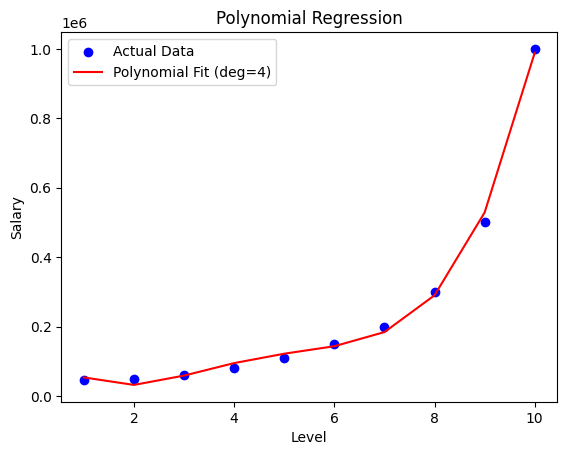

In [ ]:
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Polynomial Fit (deg=4)")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

The line above is drawn only through the 10 data points, so it looks slightly jagged. Drawing it over many evenly spaced x-values gives the true smooth curve.

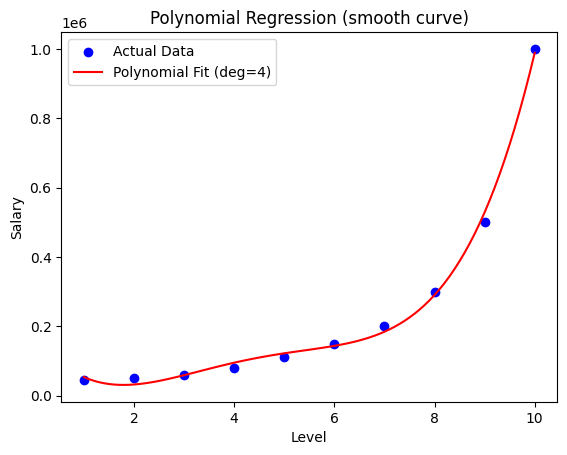

In [ ]:
X_grid = np.arange(X.min(), X.max() + 0.1, 0.1).reshape(-1, 1)

plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X_grid, poly_model.predict(poly.transform(X_grid)), color="red", label="Polynomial Fit (deg=4)")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression (smooth curve)")
plt.legend()
plt.show()

## Step 4 — Calculate the R² score and RMSE

In [ ]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("POLYNOMIAL REGRESSION METRICS:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE    : {rmse:.2f}")

POLYNOMIAL REGRESSION METRICS:
R² Score: 0.9974
RMSE    : 14503.23


## Step 5 — Compare with a straight line and other degrees

This shows why we need the polynomial: a straight line fits the data poorly.

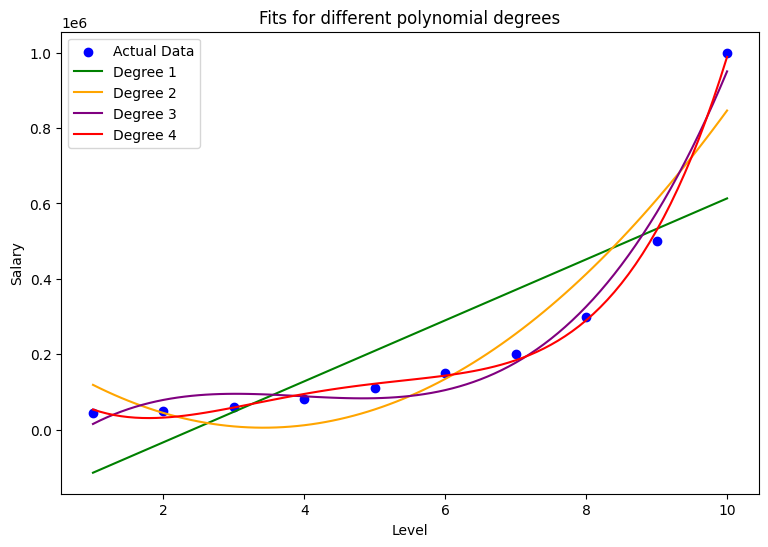

,Degree,R2,RMSE
0,1,0.6690,163388.7352
1,2,0.9162,82212.1240
2,3,0.9812,38931.5040
3,4,0.9974,14503.2349


In [ ]:
rows = []
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color="blue", label="Actual Data")

for degree, color in zip([1, 2, 3, 4], ["green", "orange", "purple", "red"]):
    pf = PolynomialFeatures(degree=degree)
    model = LinearRegression().fit(pf.fit_transform(X), y)
    pred = model.predict(pf.transform(X))
    rows.append({"Degree": degree, "R2": r2_score(y, pred), "RMSE": np.sqrt(mean_squared_error(y, pred))})
    plt.plot(X_grid, model.predict(pf.transform(X_grid)), color=color, label=f"Degree {degree}")

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Fits for different polynomial degrees")
plt.legend()
plt.show()

pd.DataFrame(rows).round(4)

### Interpretation
- A straight line (degree 1) has a low R² because salary grows non-linearly with level (it rises very steeply near the top).
- Increasing the degree makes the curve follow the data better; degree 4 gives a very high R².
- These scores are measured on the same data used for training. With only 10 points, a high degree can simply memorise the data (overfitting), so on real problems you should also check performance on a separate test set.